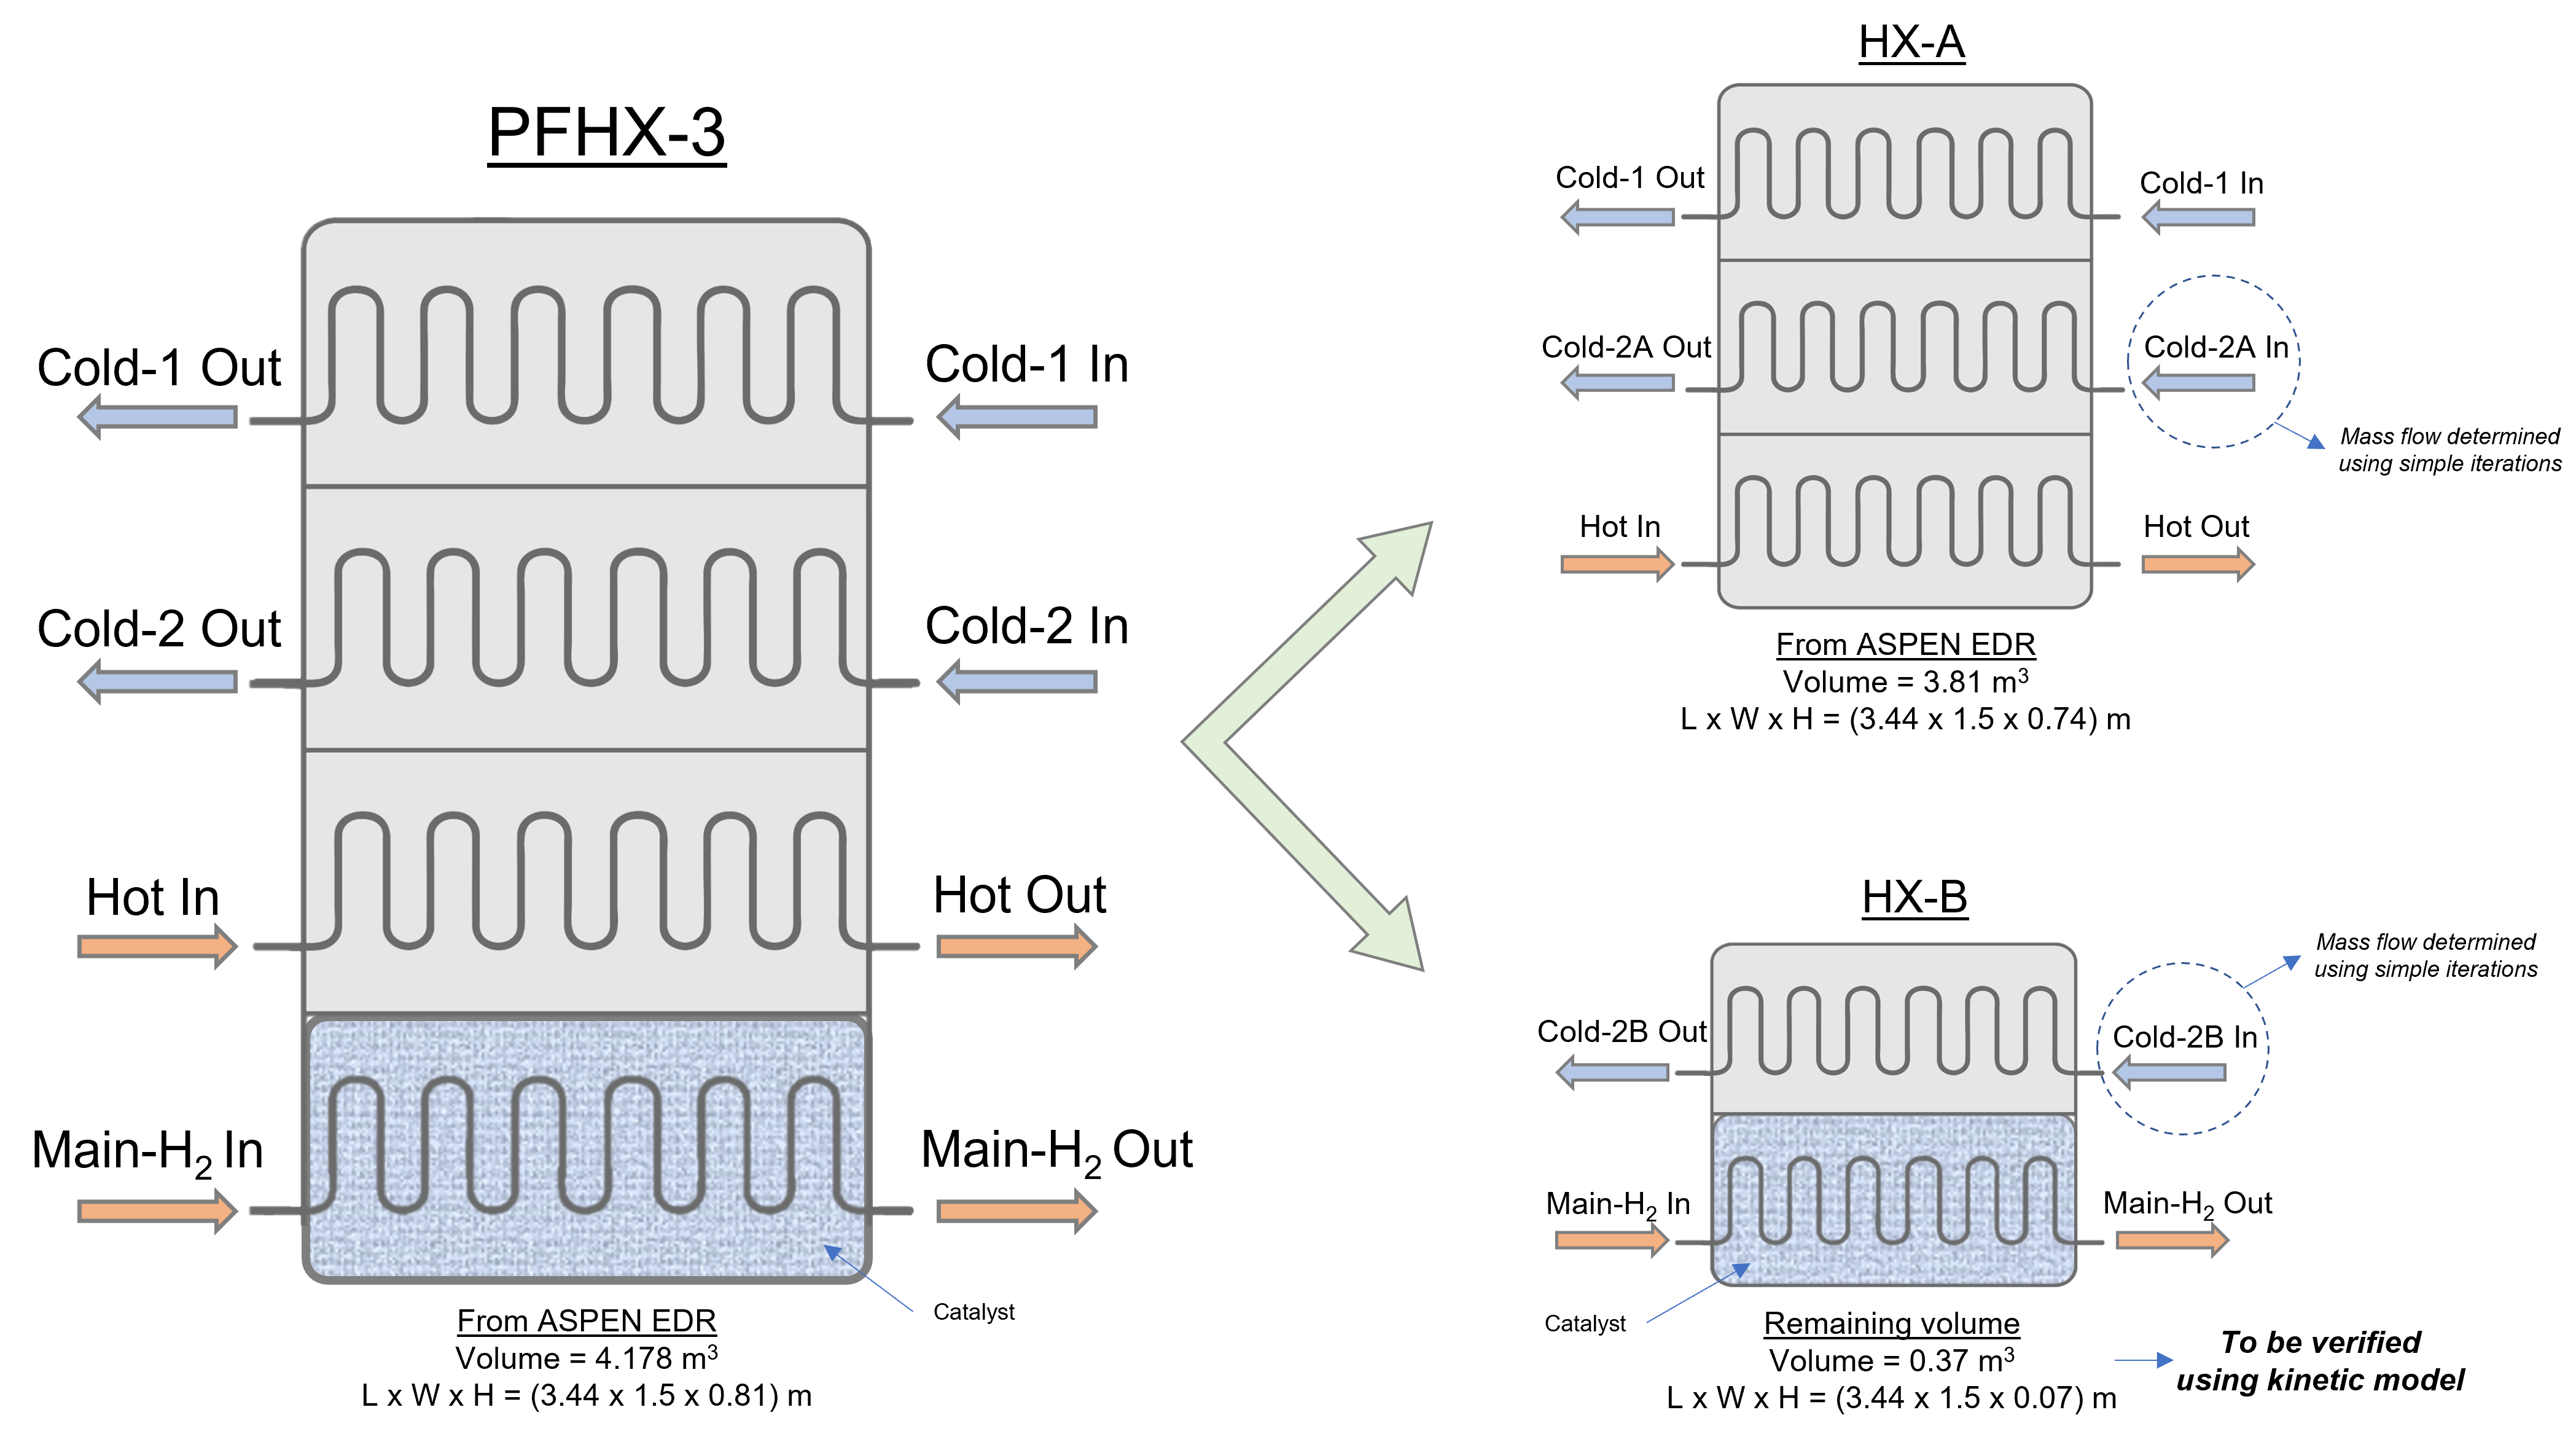

In [1]:
from hydrogen_liquefaction import streamProps

In [2]:
import math
class Format:
    end = '\033[0m'
    underline = '\033[4m'
    
print(Format.underline + "COLD STREAMS" + Format.end + "(from ASPEN HYSYS)")
cold1_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 110.999991856599, 1.1000*1e5, 2315.572061/3600, "R12")
cold1_In.printState()
cold1_Out = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 118.399996544637, 1.0500*1e5, cold1_In.M, "R13")
cold1_Out.printState()

cold2_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 102.33977, 7.594800*1e5, 49190.802051/3600, "R25")
cold2_In.printState()
cold2_Out = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 111.218525718605, 7.494800*1e5, cold2_In.M, "R26")
cold2_Out.printState()

print(Format.underline + "HOT STREAMS" + Format.end + "(from ASPEN HYSYS)")
mainH2_In = streamProps.ThermoState("TP", "REFPROP::EQHYDROGEN", 113.9999997, 19.7780*1e5, 5208.00/3600, "F03")
mainH2_In.x_para = 0.25
print("F03 p-H2 mole fraction: " + str(round(mainH2_In.x_para,3)))
mainH2_In.printState()
mainH2_Out = streamProps.ThermoState("TP", "REFPROP::EQHYDROGEN", 106.00, 19.730*1e5, mainH2_In.M, "F04")
mainH2_Out.printState()

hot_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 119.400, 29.700*1e5, 51506.37411/3600, "R02")
hot_In.printState()
hot_Out = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", 112.000, 29.60*1e5, hot_In.M, "R03")
hot_Out.printState()

##Calculating dummy streams
cold1A_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", cold1_In.T, cold1_In.P, cold1_In.M, "R12A")
cold2A_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", cold2_In.T, cold2_In.P, cold2_In.M, "R25A")

MH = cold1A_In.M*(cold1A_In.H-cold1_Out.H) + cold2A_In.M*(cold2A_In.H-cold2_Out.H) \
        + hot_In.M*(hot_In.H-hot_Out.H)

while MH < 0:
    """
    if cold1A_In.M > 0:
        cold1A_In.M -= 0.00001
        cold1A_In.M = round(cold1A_In,6)
    """
    cold2A_In.M -= 0.00001
    cold2A_In.M = round(cold2A_In.M,6)
    
    MH = cold1A_In.M*(cold1A_In.H-cold1_Out.H) + cold2A_In.M*(cold2A_In.H-cold2_Out.H) \
            + hot_In.M*(hot_In.H-hot_Out.H)

print(Format.underline + "DUMMY STREAMS" + Format.end)
cold1A_In.printState()
cold2A_In.printState()

cold1B_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", cold1_In.T, cold1_In.P, cold1_In.M-cold1A_In.M, "R12B")
cold1B_In.printState()
cold2B_In = streamProps.ThermoState("TP", "REFPROP::HYDROGEN", cold2_In.T, cold2_In.P, cold2_In.M-cold2A_In.M, "R25B")
cold2B_In.printState()

COLD STREAMS(from ASPEN HYSYS)
Stream R12
M [kg/s]    =  0.6432
P [bar]     =  1.1
T [Kelvin]  =  111.0
H [kJ/kg]   =  1429.742
S [kJ/kg.K] =  40.055


Stream R13
M [kg/s]    =  0.6432
P [bar]     =  1.05
T [Kelvin]  =  118.4
H [kJ/kg]   =  1516.03
S [kJ/kg.K] =  40.999


Stream R25
M [kg/s]    =  13.6641
P [bar]     =  7.595
T [Kelvin]  =  102.34
H [kJ/kg]   =  1321.752
S [kJ/kg.K] =  31.072


Stream R26
M [kg/s]    =  13.6641
P [bar]     =  7.495
T [Kelvin]  =  111.22
H [kJ/kg]   =  1424.875
S [kJ/kg.K] =  32.093


HOT STREAMS(from ASPEN HYSYS)
F03 p-H2 mole fraction: 0.25
Stream F03
M [kg/s]    =  1.4467
P [bar]     =  19.778
T [Kelvin]  =  114.0
H [kJ/kg]   =  1911.929
S [kJ/kg.K] =  36.892


Stream F04
M [kg/s]    =  1.4467
P [bar]     =  19.73
T [Kelvin]  =  106.0
H [kJ/kg]   =  1799.713
S [kJ/kg.K] =  35.881


Stream R02
M [kg/s]    =  14.3073
P [bar]     =  29.7
T [Kelvin]  =  119.4
H [kJ/kg]   =  1501.755
S [kJ/kg.K] =  27.056


Stream R03
M [kg/s]    =  14.3073
P [bar]     = 

In [3]:
print(MH)
A = cold1_In.M*(cold1_In.H-cold1_Out.H) + cold2_In.M*(cold2_In.H-cold2_Out.H) + hot_In.M*(hot_In.H-hot_Out.H) + mainH2_In.M*(mainH2_In.H-mainH2_Out.H)
print(A)
mh = cold2B_In.M*(cold2B_In.H-cold2_Out.H)+ mainH2_In.M*(mainH2_In.H-mainH2_Out.H)
print(mh)

0.5392643378581852
64.45053953494062
63.91127519716974


In [4]:
lengthPFHX = 1.5996
widthPFHX = 1.5000
heightPFHX = 1.6309
volumePFHX = lengthPFHX*widthPFHX*heightPFHX

print(Format.underline + "Overall PFHX Geometry" + Format.end)
print("(based on ASPEN EDR)")
print("Length [m]  = ", lengthPFHX)
print("Width  [m]  = ", widthPFHX)
print("Height [m]  = ", heightPFHX)
print("Volume [m3] = ", round(volumePFHX,3))
print("\n")

lengthHXA     = 1.45101
widthHXA      = 1.5000
heightHXA     = 1.4645
volumeHXA     = lengthHXA*widthHXA*heightHXA

print(Format.underline + "HXA Geometry" + Format.end)
print("(based on ASPEN EDR)")
print("Length [m]  = ", lengthHXA)
print("Width  [m]  = ", widthHXA)
print("Height [m]  = ", heightHXA)
print("Volume [m3] = ", round(volumeHXA,3))
print("\n")

volumeHXB     = volumePFHX - volumeHXA
lengthHXB     = lengthPFHX
widthHXB      = widthPFHX
heightHXB     = volumeHXB/(lengthHXB*widthHXB)
print(Format.underline + "HXB Geometry" + Format.end)
print("Length [m]  = ", lengthHXB)
print("Width  [m]  = ", widthHXB)
print("Height [m]  = ", round(heightHXB,3))
print("Volume [m3] = ", round(volumeHXB,3))
print("\n")

Overall PFHX Geometry
(based on ASPEN EDR)
Length [m]  =  1.5996
Width  [m]  =  1.5
Height [m]  =  1.6309
Volume [m3] =  3.913


HXA Geometry
(based on ASPEN EDR)
Length [m]  =  1.45101
Width  [m]  =  1.5
Height [m]  =  1.4645
Volume [m3] =  3.188


HXB Geometry
Length [m]  =  1.5996
Width  [m]  =  1.5
Height [m]  =  0.302
Volume [m3] =  0.726




Adjusted Overall PFHX Geometry
(based on ASPEN EDR)
Length [m]  =  1.5996
Width  [m]  =  1.5
Height [m]  =  1.6309
Volume [m3] =  3.913


HXB Geometry
Length [m]  =  1.5996
Width  [m]  =  1.5
Height [m]  =  0.302
Volume [m3] =  0.726

###### Running Simulation ######
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          1.78e-06       0.00e+00          50              0       
Solved in 1 iterations, number of nodes 50. 
Maximum relative residual: 1.78e-06 
Maximum boundary residual: 0.00e+00


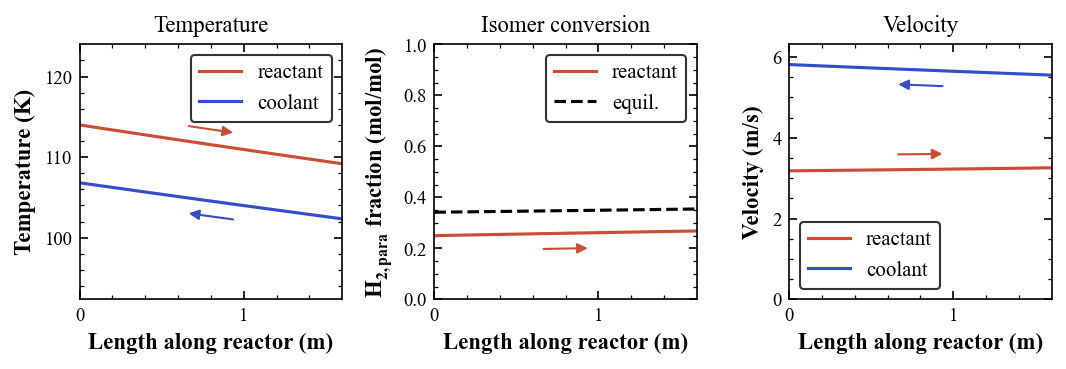

In [5]:
# test for verifying model

### CONFIGURATION ###
configuration = {
    'reactant': {
        'mass_flow_rate': mainH2_In.M*86.4, # tonne-per-day
        'x_para': mainH2_In.x_para,         # para-hydrogen fraction at inlet
        'temperature': mainH2_In.T,         # inlet temperature (K)
        'pressure': mainH2_In.P/1000        # inlet pressure (kPa)
    },
    'coolant': {
        'fluid': "Hydrogen",          # type of coolant
        'x_para': 0.25,               # normal hydrogen
        'mass_flow_rate': cold2B_In.M*86.4,  # tonne-per-day
        'temperature':  cold2B_In.T,        # temperature of coolant at inlet (K)
        'pressure': cold2B_In.P/1000        # pressure of coolant at inlet (kPa)
    },
    'reactor': {
        'length': lengthHXB,                # m
        'width': widthHXB,                 # m
        'height': heightHXB,                # m
        'fin_thickness': 0.2e-3,      # m
        'fin_height': 8.9e-3,         # m
        'fin_pitch': 1.27e-3,         # m
        'seration_length': 3.0e-3,    # m
        'parting_sheet_thickness': 1.5e-3 # m
    },
    'catalyst': {
        'solid_fraction': 0.31,       # volumetric fraction of catlayst particles within reactor
        'diameter': 424.0e-6,         # mean particle diameter
        'density': 4.0                # solid density of catalyst particles (g/cm3)
    },
    'simulation': {
        'nodes': 50,                  # number of nodes across reactor length to setup
        'tolerance': 1.0e-4,          # tolerance of bvp solver
        'delta_t': 1.0                # initial guess of temperature difference between streams
    }
}

# import packages
import matplotlib
from hydrogen_pfhx import model, outputs

print(Format.underline + "Adjusted Overall PFHX Geometry" + Format.end)
print("(based on ASPEN EDR)")
print("Length [m]  = ", lengthPFHX)
print("Width  [m]  = ", widthPFHX)
print("Height [m]  = ", heightPFHX)
print("Volume [m3] = ", round(volumePFHX,3))
print("\n")

print(Format.underline + "HXB Geometry" + Format.end)
print("Length [m]  = ", lengthHXB)
print("Width  [m]  = ", widthHXB)
print("Height [m]  = ", round(heightHXB,3))
print("Volume [m3] = ", round(volumeHXB,3))

# run the model with config
print('\n###### Running Simulation ######')
results = model.model(configuration)

# plot & display results!
outputs.plot_results(results)
matplotlib.pyplot.draw()
matplotlib.pyplot.savefig('HX-3_init.png')

Adjusted Overall PFHX Geometry
(based on ASPEN EDR)
Length [m]  =  4.0
Width  [m]  =  1.5
Height [m]  =  3.0
Volume [m3] =  18.0


HXB Geometry
Length [m]  =  4.0
Width  [m]  =  1.5
Height [m]  =  1.536
Volume [m3] =  9.213

###### Running Simulation ######
   Iteration    Max residual  Max BC residual  Total nodes    Nodes added  
       1          2.23e-02       0.00e+00          50             75       
       2          1.14e-06       0.00e+00          125             0       
Solved in 2 iterations, number of nodes 125. 
Maximum relative residual: 1.14e-06 
Maximum boundary residual: 0.00e+00


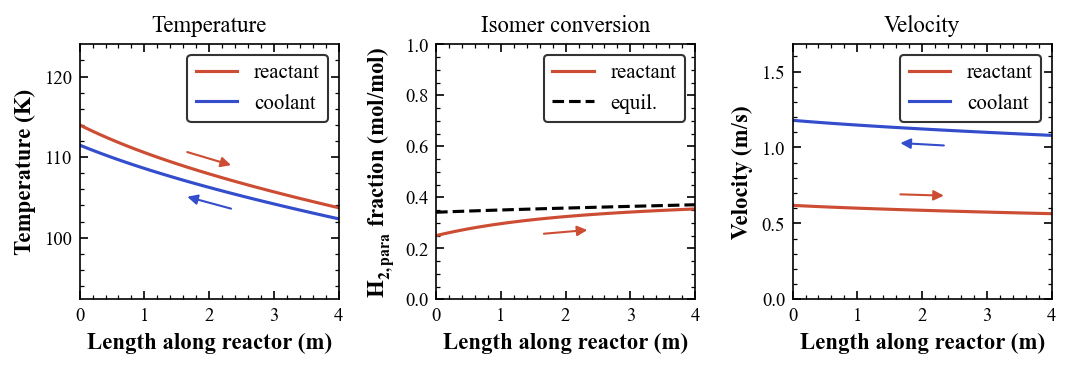

In [6]:
#Adjusted geometry
lengthPFHX = 4.0
widthPFHX = 1.5
heightPFHX = 3.0
volumePFHX = lengthPFHX*widthPFHX*heightPFHX

lengthHXB     = lengthPFHX
widthHXB      = widthPFHX
heightHXB     = heightPFHX - heightHXA
volumeHXB     = lengthHXB*widthHXB*heightHXB

# test for verifying model

### CONFIGURATION ###
configuration = {
    'reactant': {
        'mass_flow_rate': mainH2_In.M*86.4, # tonne-per-day
        'x_para': mainH2_In.x_para,         # para-hydrogen fraction at inlet
        'temperature': mainH2_In.T,         # inlet temperature (K)
        'pressure': mainH2_In.P/1000        # inlet pressure (kPa)
    },
    'coolant': {
        'fluid': "Hydrogen",          # type of coolant
        'x_para': 0.25,               # normal hydrogen
        'mass_flow_rate': cold2B_In.M*86.4,  # tonne-per-day
        'temperature':  cold2B_In.T,        # temperature of coolant at inlet (K)
        'pressure': cold2B_In.P/1000        # pressure of coolant at inlet (kPa)
    },
    'reactor': {
        'length': lengthHXB,                # m
        'width': widthHXB,                 # m
        'height': heightHXB,                # m
        'fin_thickness': 0.2e-3,      # m
        'fin_height': 8.9e-3,         # m
        'fin_pitch': 1.27e-3,         # m
        'seration_length': 3.0e-3,    # m
        'parting_sheet_thickness': 1.5e-3 # m
    },
    'catalyst': {
        'solid_fraction': 0.31,       # volumetric fraction of catlayst particles within reactor
        'diameter': 424.0e-6,         # mean particle diameter
        'density': 4.0                # solid density of catalyst particles (g/cm3)
    },
    'simulation': {
        'nodes': 50,                  # number of nodes across reactor length to setup
        'tolerance': 1.0e-4,          # tolerance of bvp solver
        'delta_t': 1.0                # initial guess of temperature difference between streams
    }
}

# import packages
import matplotlib
from hydrogen_pfhx import model, outputs

print(Format.underline + "Adjusted Overall PFHX Geometry" + Format.end)
print("(based on ASPEN EDR)")
print("Length [m]  = ", lengthPFHX)
print("Width  [m]  = ", widthPFHX)
print("Height [m]  = ", heightPFHX)
print("Volume [m3] = ", round(volumePFHX,3))
print("\n")

print(Format.underline + "HXB Geometry" + Format.end)
print("Length [m]  = ", lengthHXB)
print("Width  [m]  = ", widthHXB)
print("Height [m]  = ", round(heightHXB,3))
print("Volume [m3] = ", round(volumeHXB,3))

# run the model with config
print('\n###### Running Simulation ######')
results = model.model(configuration)

# plot & display results!
outputs.plot_results(results)
matplotlib.pyplot.draw()
matplotlib.pyplot.savefig('HX-3_final.png')

In [7]:
print(results)

        Z (m)  Reactant pressure (kPa)  Coolant pressure (kPa)  \
0    0.000000              1977.800000              759.200294   
1    0.040816              1977.658260              759.203324   
2    0.081633              1977.516738              759.206350   
3    0.122449              1977.375429              759.209371   
4    0.163265              1977.234331              759.212387   
..        ...                      ...                     ...   
120  3.836735              1965.163271              759.469140   
121  3.877551              1965.034612              759.471859   
122  3.918367              1964.906053              759.474575   
123  3.959184              1964.777594              759.477289   
124  4.000000              1964.649235              759.480000   

     Reactant temperature (K)  Coolant temperature (K)  \
0                  114.000000               111.497569   
1                  113.836724               111.363838   
2                  113.675907    